最新数据日期：2023-07-11
             open   high    low  close     volume
2023-07-05  25.35  25.49  24.90  25.03   783406.0
2023-07-06  25.13  25.29  24.79  25.02   725400.0
2023-07-07  25.02  25.29  24.84  25.06   652600.0
2023-07-10  24.85  25.70  24.85  25.67  1419251.0
2023-07-11  25.74  25.74  25.11  25.36  1107737.0


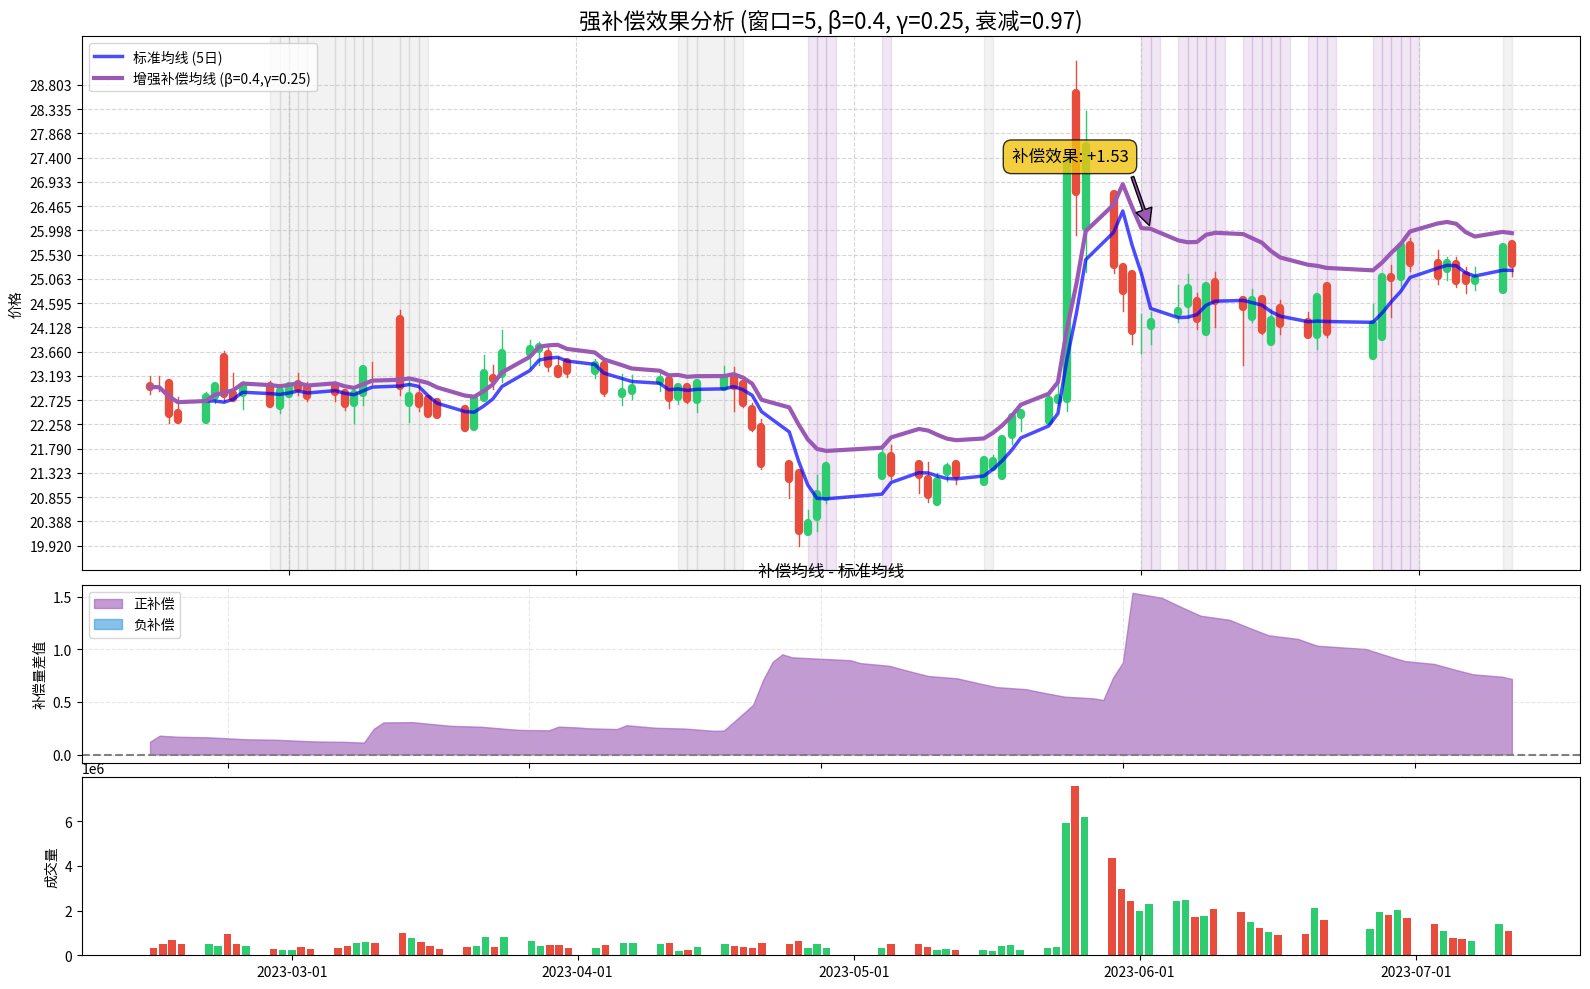

In [8]:
# 完整技术分析看盘程序 v1.0

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
import argparse
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from matplotlib.dates import DateFormatter
from matplotlib.patches import Rectangle
from scipy.signal import find_peaks
from scipy.stats import linregress
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats, signal, cluster


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
import pandas as pd
import numpy as np

def calculate_compensated_ma(close, window=20, beta=0.3, gamma=0.2, decay_factor=0.95):
    """
    增强版补偿移动平均线计算函数
    
    参数:
        close (pd.Series): 收盘价序列
        window (int): 窗口大小
        beta (float): 基础补偿系数 (0.2-0.5)
        gamma (float): 趋势增强系数 (0.1-0.3)
        decay_factor (float): 补偿衰减因子 (0.9-0.99)
    
    返回:
        pd.Series: 补偿均线序列
    """
    cma = np.full(len(close), np.nan)  # 初始化补偿均线数组
    data_queue = []                    # 数据窗口
    current_sum = 0.0                  # 当前窗口和
    prev_mean = 0.0                    # 前一次均线值
    cumulative_compensation = 0.0      # 累积补偿量
    trend_strength = 0.0               # 趋势强度
    
    for i, price in enumerate(close):
        # 添加新值
        data_queue.append(price)
        current_sum += price
        
        # 计算趋势强度（基于价格变化）
        if i > 0:
            price_change = price - close.iloc[i-1]
            trend_strength = 0.7 * trend_strength + 0.3 * (1 if price_change > 0 else -1)
        
        # 如果窗口已满
        if len(data_queue) > window:
            # 移除最旧的值
            removed = data_queue.pop(0)
            current_sum -= removed
            
            # 计算补偿量（增强版）
            if removed > prev_mean:
                # 基础补偿 + 趋势增强补偿
                base_compensation = beta * (removed - prev_mean)
                trend_enhancement = gamma * abs(trend_strength) * (removed - prev_mean)
                compensation = base_compensation + trend_enhancement
                
                # 累积补偿并应用衰减
                cumulative_compensation = cumulative_compensation * decay_factor + compensation
            else:
                compensation = 0
                # 低值移出时减少累积补偿
                cumulative_compensation *= decay_factor
        else:
            compensation = 0
            cumulative_compensation = 0
        
        # 计算当前标准均线
        n = len(data_queue)
        standard_mean = current_sum / n
        
        # 计算补偿均线（包含累积补偿）
        current_mean = standard_mean + cumulative_compensation
        cma[i] = current_mean
        prev_mean = current_mean
    
    return pd.Series(cma, index=close.index)

def plot_ohlc_with_enhanced_compensated_ma(df, window=20, beta=0.3, gamma=0.2, decay=0.95, title='增强补偿均线分析'):
    """
    绘制K线图与增强版补偿均线
    
    参数:
        df (pd.DataFrame): 包含OHLC数据的DataFrame
        window (int): 均线窗口大小
        beta (float): 基础补偿系数
        gamma (float): 趋势增强系数
        decay (float): 补偿衰减因子
        title (str): 图表标题
    """
    # 确保列名是小写
    df = df.rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close',
        'OPEN': 'open', 'HIGH': 'high', 'LOW': 'low', 'CLOSE': 'close'
    })
    
    # 计算标准均线和补偿均线
    df['sma'] = df['close'].rolling(window=window).mean()
    df['cma'] = calculate_compensated_ma(df['close'], window, beta, gamma, decay)
    
    # 计算补偿量差值
    df['compensation_diff'] = df['cma'] - df['sma']
    
    # 创建图表
    plt.figure(figsize=(16, 10), dpi=100)
    gs = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1])
    ax1 = plt.subplot(gs[0])  # K线和均线
    ax2 = plt.subplot(gs[1])  # 补偿量差值
    ax3 = plt.subplot(gs[2])  # 成交量
    
    # 设置日期格式
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    for ax in [ax1, ax2, ax3]:
        ax.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    
    # 绘制K线
    for i in range(len(df)):
        date = df.index[i]
        open_price = df['open'].iloc[i]
        high_price = df['high'].iloc[i]
        low_price = df['low'].iloc[i]
        close_price = df['close'].iloc[i]
        
        # 确定K线颜色
        color = '#2ecc71' if close_price >= open_price else '#e74c3c'  # 更鲜明的颜色
        
        # 绘制K线实体
        ax1.plot([date, date], [open_price, close_price], 
                color=color, linewidth=6, solid_capstyle='round')
        
        # 绘制上下影线
        ax1.plot([date, date], [low_price, high_price], 
                color=color, linewidth=1)
    
    # 绘制均线 - 使用更粗的线宽和更鲜明的颜色
    ax1.plot(df.index, df['sma'], 'b-', linewidth=2.5, label=f'标准均线 ({window}日)', alpha=0.7)
    ax1.plot(df.index, df['cma'], '#9b59b6', linewidth=3.0, label=f'增强补偿均线 (β={beta},γ={gamma})')  # 紫色
    
    # 在关键位置标注补偿效果
    if len(df) > window + 10:
        # 找到最大补偿差异点
        max_diff_idx = np.nanargmax(df['compensation_diff'].values)
        max_diff_date = df.index[max_diff_idx]
        max_diff_value = df['compensation_diff'].iloc[max_diff_idx]
        
        # 添加箭头标注
        ax1.annotate(f'补偿效果: +{max_diff_value:.2f}', 
                    xy=(max_diff_date, df['cma'].iloc[max_diff_idx]),
                    xytext=(max_diff_date - pd.Timedelta(days=15), 
                           df['cma'].iloc[max_diff_idx] * 1.05),
                    arrowprops=dict(facecolor='#9b59b6', shrink=0.05, width=2),
                    fontsize=12, 
                    bbox=dict(boxstyle='round,pad=0.5', fc='#f1c40f', alpha=0.8))
        
        # 在补偿差异大的区域添加阴影
        high_compensation = df['compensation_diff'] > df['compensation_diff'].quantile(0.75)
        for i in range(len(df)):
            if i < window: 
                continue
            if high_compensation.iloc[i]:
                ax1.axvspan(df.index[i], df.index[i] + pd.Timedelta(days=1), 
                           alpha=0.15, color='#9b59b6')
    
    # 绘制补偿量差值
    ax2.fill_between(df.index, 0, df['compensation_diff'], 
                    where=(df['compensation_diff'] > 0), 
                    color='#9b59b6', alpha=0.6, label='正补偿')
    ax2.fill_between(df.index, 0, df['compensation_diff'], 
                    where=(df['compensation_diff'] < 0), 
                    color='#3498db', alpha=0.6, label='负补偿')
    ax2.axhline(0, color='gray', linestyle='--')
    ax2.set_ylabel('补偿量差值')
    ax2.set_title('补偿均线 - 标准均线', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.legend(loc='upper left')
    
    # 绘制成交量（如果有）
    if 'volume' in df.columns:
        # 确定成交量柱状图颜色
        colors = ['#2ecc71' if close_price >= open_price else '#e74c3c'
                 for close_price, open_price in zip(df['close'], df['open'])]
        
        ax3.bar(df.index, df['volume'], color=colors, width=0.8)
        ax3.set_ylabel('成交量')
    
    # 添加标题和标签
    ax1.set_title(f'{title} (窗口={window}, β={beta}, γ={gamma}, 衰减={decay})', fontsize=16)
    ax1.set_ylabel('价格')
    ax1.legend(loc='best')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 添加价格区间网格
    price_min, price_max = df['low'].min(), df['high'].max()
    price_range = price_max - price_min
    grid_step = price_range / 20
    ax1.yaxis.set_ticks(np.arange(price_min, price_max, grid_step))
    
    # 添加横盘区域检测
    if len(df) > 50:
        rolling_std = df['close'].rolling(10).std()
        low_volatility = rolling_std < rolling_std.quantile(0.3)
        
        for i in range(1, len(df)):
            if low_volatility.iloc[i] and low_volatility.iloc[i-1]:
                ax1.axvspan(df.index[i-1], df.index[i], 
                           alpha=0.1, color='gray', zorder=-1)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05)  # 减少子图间距
    plt.show()



    
    

# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='301053.SZ',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20230711',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=100,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    # 使用强补偿参数
    plot_ohlc_with_enhanced_compensated_ma(
        df,
        window=5,
        beta=0.4,
        gamma=0.25,
        decay=0.97,
        title='强补偿效果分析'
    )